# ASTR 596 Computer lab - Image combination and photometry (50 points)

## <font color = 'red'> Answer Key - see red comments throughout on how to change exercise </font>

In this lab you will learn how to:
* combine a set of astrometrically aligned images
* measure the size of stars in each of these images
* measure fluxes of objects in each image
* convert these to magnitudes
* match sources in the two catalogs
* plot H-R diagrams for the cluster

<i>Note: Enter in all code to the problems in the provided notebook cells. Questions to answer will be <b>bolded</b>.</i>  

All your answers should be entered in this notebook. Each student will need to hand in their own notebook by uploading it to GitHub following the instructions.

In the code places where you will need to put something or write your own code are specified by `#***************`  You will not get points for doing this unless explicitly noted.  Some of these things are just to make sure you are setting up your paths correctly.

**Due on Nov. 18 at Noon** to be handed into the "Image Combinaton and Photometry" assignment in Module 8.

Thanks to Prof. Rose Finn for her work in reducing the individual images of M29 and for providing them to us.

**You will need to download the raw data.  You can access it at**

**https://www.dropbox.com/t/wqpOzykI2Q9vznIF**

I suggest you make a directory on your computer called `~/ASTR596/Data` and put data in there.  

In [1]:
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats
from photutils.aperture import CircularAperture
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.io import fits
import glob
import os
from scipy.stats import scoreatpercentile

from matplotlib import pyplot as plt
import numpy as np

#import ccdproc

from astropy.nddata import CCDData
import astropy.units as u
from ccdproc import ImageFileCollection, Combiner, combine
from ccdproc import wcs_project


### Some functions to display the images and overplot the stars

In [2]:
def imdisplay(image, v1perc=10, v2perc=95):
    '''
    display an image 
    OPTIONAL KEYWORD PARAMETERS
    v1perc: one end of the colormap assigned to the v1perc percent lowest flux 
    v2perc: the other end of the colormap assigned to the v2perc percent highest flux    
    '''
    # make sure image is an np array
    nimage = np.array(image)
    # determine the pixel values at the 10th and 95th percentile
    v1 = scoreatpercentile(nimage,v1perc)
    v2 = scoreatpercentile(nimage,v2perc)
    # display using imshow
    #
    # you can play with alternate cmaps in the function below, such as "viridis" or "gray"
    # The 'gray_r' color map reverses the color-scale so that dark display pixels are the brightest in the image
    #
    # vmin and vmax set the min and max pixel values that
    # will be mapped to the extremes of the colormap
    plt.imshow(nimage,cmap='gray_r',vmin=v1,vmax=v2)
    plt.colorbar(fraction=.08)
    
def add_stars(xstars,ystars,radius=20,color='r',ax=None):
    ''' this will add circles at the location of xstars,ystars '''
    if ax is None:
        ax = plt.gca()
    allcircles=[]
    #The zip function takes iterables (e.g. lists or arrays) and groups them into tuples that contain 
    #matched pairs of each input, e.g [(x,y)]
    for x,y in zip(xstars,ystars):
        c = plt.Circle((x,y),radius,color=color,fill=False)
        #allcircles.append(c)
        ax.add_artist(c)

In [3]:
#set the directory with your data
#*********************
#you will need to modify this with your own directory
datadir = '/Users/grudnick/Work/Teaching/Classes/Astro_596/Fall_2024/Observing/Data/M29_cal'

#change directory to the data directory
os.chdir(datadir)


### Display one image in each filter 
This will let you see what the data in each filter looks like.  There are multiple images taken in each band.  The following blocks of code each display the first image taken in each band.

Text(0.5, 1.0, 'B-band image')

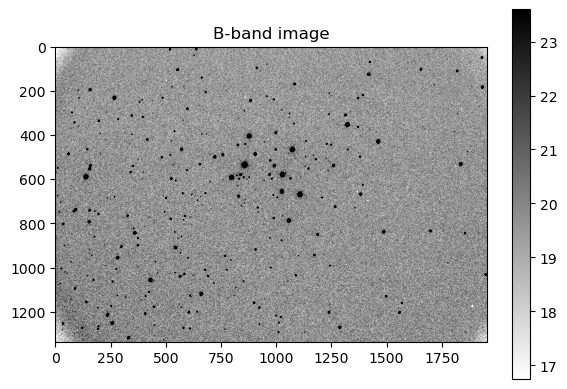

In [4]:
#make the figure
plt.figure()

#read in the data and header
data,header = fits.getdata('cazfdp-M29-0001b.fits', header=True)

#use our custom made subroutine from above to plot the image
imdisplay(data)
plt.title("B-band image")

Text(0.5, 1.0, 'V-band image')

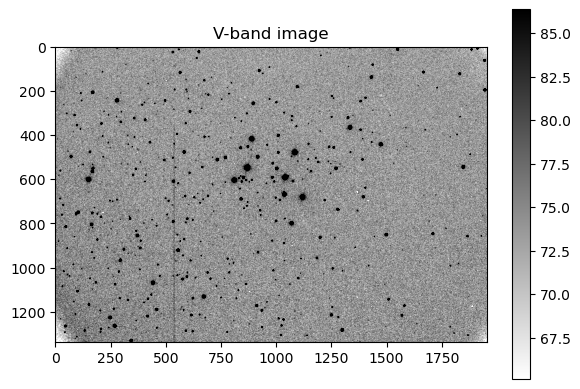

In [5]:
#make the figure
plt.figure()

#read in the data and header
data,header = fits.getdata('cazfdp-M29-0001g.fits', header=True)

#use our custom made subroutine from above to plot the image
imdisplay(data)
plt.title("V-band image")

Text(0.5, 1.0, 'R-band image')

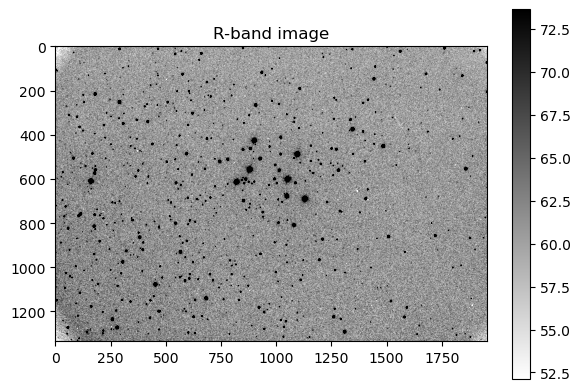

In [6]:
#make the figure
plt.figure()

#read in the data and header
data,header = fits.getdata('cazfdp-M29-0001r.fits', header=True)

#use our custom made subroutine from above to plot the image
imdisplay(data)
plt.title("R-band image")

### determine how subsequent images in a single band differ

Use ds9 to display the 0001, 0002, and 0003 images for the $B$ band.  Display each image in a separate frame by creating a new frame in the horizontal button bar and opening the file into that frame.  Use the `scale->zscale` button to display the stretch better.

By hitting the Tab key you can cycle through the images.  Shift-Tab cycles through them in reverse order.  You can also use the Blink button or the Tile button under the Frame button to blink the images.

### Problem 1 (6 points)
What is the main difference between the different individual images within a single band?  Be quantitative whenever possible.

**put answer here**: The sources move around because we dithered the observations.

### Combine the images in each filter.

Reference: https://ccdproc.readthedocs.io/en/latest/image_combination.html

Note: $BVR$ images have extensions $bgr$ in our data set.  These images have had their bias correction, dark current, flatfielding, astrometry, and photometric zeropoint all measured and have had cosmicrays removed.

We will use a new task called `glob.glob` which finds all the files in a current directory that match a certain syntax.

The image combination has multiple steps
* get a list of the images in each band.  
* Each image has a slightly different pointing because the telescope was dithered around.
* establish which WCS you will use as a target onto which all the other images will be aligned.
* use a task called `reproject` to align all of the images using the reference
* Students will need to write code to combine 2 of the 3 sets of images.


In [7]:
#for example, to get a list of all the images
image_list = glob.glob('ca*.fits')
print(image_list)

['cazfdp-M29-0005b.fits', 'cazfdp-M29-0003b.fits', 'cazfdp-M29-0001b.fits', 'cazfdp-M29-0004b.fits', 'cazfdp-M29-0002b.fits', 'cazfdp-M29-0003g.fits', 'cazfdp-M29-0003r.fits', 'cazfdp-M29-0001r.fits', 'cazfdp-M29-0001g.fits', 'cazfdp-M29-0005g.fits', 'cazfdp-M29-0005r.fits', 'cazfdp-M29-0002g.fits', 'cazfdp-M29-0002r.fits', 'cazfdp-M29-0004g.fits', 'cazfdp-M29-0004r.fits']


In [8]:
#*****************
#Using the above code as a reference, create lists of images in each band
#First we need to get a list for images in each filter
#CHANGE TO REMOVE FILENAMES
rimage_list = glob.glob('ca*r.fits')
gimage_list = glob.glob('ca*g.fits')
bimage_list = glob.glob('ca*b.fits')

#read in the first r-band image in that list using fits.getdata.  This image will be used as a target whose WCS
# will be used for all other images to be transformed onto
rimage, rheader = fits.getdata(rimage_list[0],header=True)
target_wcs = WCS(header)

print(target_wcs)
#**********************
#now print out each of the image lists to see if they make sense
#CHANGE TO REMOVE LIST NAMES
print(rimage_list)
print(gimage_list)
print(bimage_list)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 305.979554574 38.5221094171 
CRPIX : 977.5 668.5 
CD1_1 CD1_2  : 0.000213779024462 -6.70567456134e-05 
CD2_1 CD2_2  : 6.71084281872e-05 0.000213787720685 
NAXIS : 1954  1336
['cazfdp-M29-0003r.fits', 'cazfdp-M29-0001r.fits', 'cazfdp-M29-0005r.fits', 'cazfdp-M29-0002r.fits', 'cazfdp-M29-0004r.fits']
['cazfdp-M29-0003g.fits', 'cazfdp-M29-0001g.fits', 'cazfdp-M29-0005g.fits', 'cazfdp-M29-0002g.fits', 'cazfdp-M29-0004g.fits']
['cazfdp-M29-0005b.fits', 'cazfdp-M29-0003b.fits', 'cazfdp-M29-0001b.fits', 'cazfdp-M29-0004b.fits', 'cazfdp-M29-0002b.fits']


###  Combine the images

Text(0.5, 1.0, 'R-band image')

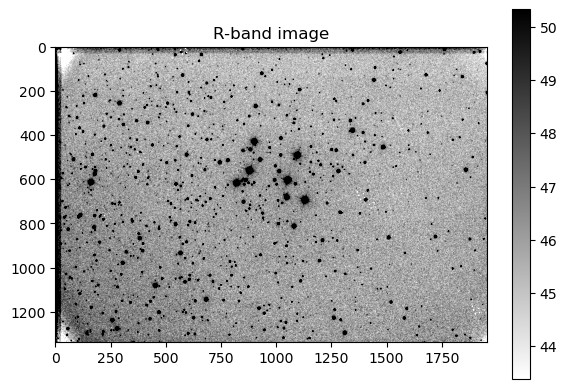

In [9]:
# We will reproject all the images to align them with the first image in each of the lists for a given filter.
#start with the R-band data
reprojected = []
#loop through each image name
for image_name in rimage_list:
    #read the image into a "CCDData" object
    img = CCDData.read(image_name)
    #take each image, and reproject it onto an identical coordinate grid to the target image
    new_image = wcs_project(img, target_wcs)
    #this is a list of all the reprojected images
    reprojected.append(new_image)

# combine the reprojected images into one image
combiner = Combiner(reprojected)
stacked_image = combiner.average_combine()


# save the combined image
fits.writeto('M29R.fits',stacked_image,overwrite=True,header=rheader)
# display the combined image
plt.figure()
imdisplay(stacked_image)
plt.title('R-band image')

## Problem 2a (4 points) - combine exposures for the V and B-band images

You must new repeat this for the V and B-band images and trim all three images to remove bad data at the edges of the image.

/Users/grudnick/micromamba/envs/stenv/lib/python3.12/site-packages/ccdproc/combiner.py:548: RuntimeWarning: Mean of empty slice
  mean = scale_func(data, axis=0)
/Users/grudnick/micromamba/envs/stenv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 1.0, 'V-band image')

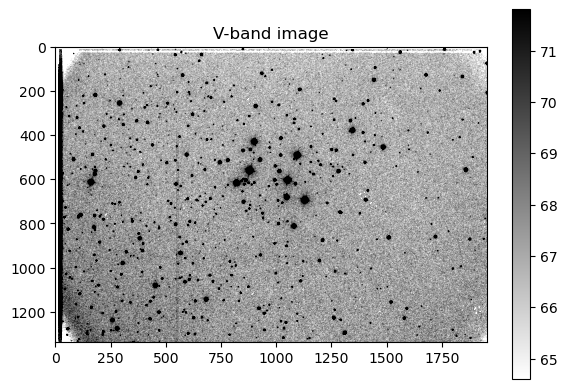

In [10]:
#*********************
#CHANGE TO REMOVE ALL CODE
#repeat for the V-band images
reprojected = []
#loop through each image name
for image_name in gimage_list:
    #read the image into a "CCDData" object
    img = CCDData.read(image_name)
    #take each image, and reproject it onto an identical coordinate grid to the target image
    new_image = wcs_project(img, target_wcs)
    #this is a list of all the reprojected images
    reprojected.append(new_image)

# combine the reprojected images into one image
combiner = Combiner(reprojected)
stacked_image = combiner.average_combine()


# save the combined image
fits.writeto('M29V.fits',stacked_image,overwrite=True,header=rheader)
# display the combined image
plt.figure()
imdisplay(stacked_image)
plt.title('V-band image')

/Users/grudnick/micromamba/envs/stenv/lib/python3.12/site-packages/ccdproc/combiner.py:548: RuntimeWarning: Mean of empty slice
  mean = scale_func(data, axis=0)
/Users/grudnick/micromamba/envs/stenv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 1.0, 'B-band image')

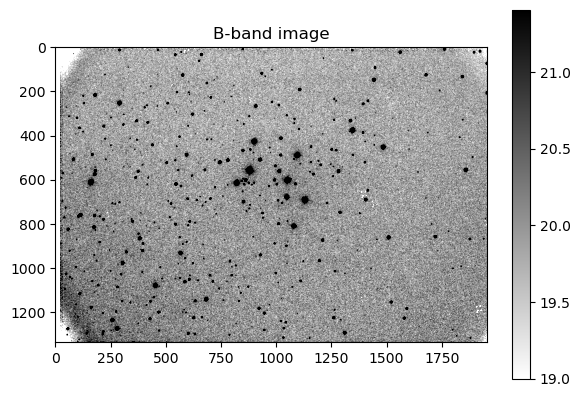

In [11]:
#*********************
#CHANGE TO REMOVE ALL CODE
#repeat for the B-band images
reprojected = []
#loop through each image name
for image_name in bimage_list:
    #read the image into a "CCDData" object
    img = CCDData.read(image_name)
    #take each image, and reproject it onto an identical coordinate grid to the target image
    new_image = wcs_project(img, target_wcs)
    #this is a list of all the reprojected images
    reprojected.append(new_image)

# combine the reprojected images into one image
combiner = Combiner(reprojected)
stacked_image = combiner.average_combine()


# save the combined image
fits.writeto('M29B.fits',stacked_image,overwrite=True,header=rheader)
# display the combined image
plt.figure()
imdisplay(stacked_image)
plt.title('B-band image')

## Problem 2b (2 points) - How would you remove cosmicrays?

Assume that there are some cosmicrays in each of the individual images in each band.  Using the manual for image combnination that is linked to right after problem one, describe how you would alter the code above to reject cosmicrays as part of the combination.  You may try to combine the images with this method.


**put answer here**: 


### What if we want to display our images using RA and DEC?

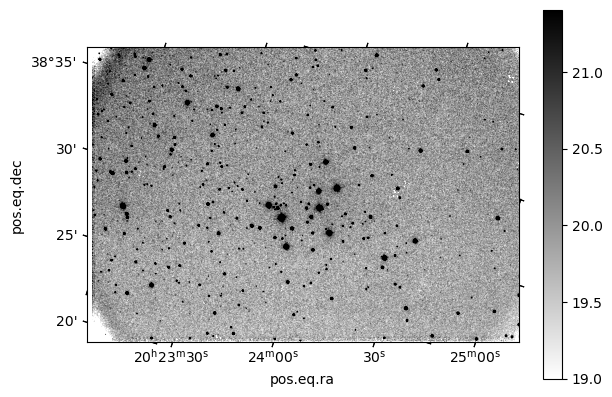

In [12]:
plt.subplot(projection=target_wcs)
imdisplay(stacked_image)

## Problem 3 - Measure the FWHM of stars using imexam (6 points)

## This problem is currently not working because of a problem with imexam.  For now use a placeholder value of the FWHM of 2.5 pixels in problem 4 and we will update it later when I can fix this part. *skip it for now*

imexam is a powerful image quick look tool to examine the images.  More info is at https://imexam.readthedocs.io/en/0.9.1/index.html

As it is a finiky package, to use it we will need to make a new environment.  You should do so with the following command from a new prompt that is in your base conda environment:

<font color=red>conda create --name env1 python==3.10.12 astropy==5.2.2 astroplan astroquery jupyter imexam ccdproc --channel conda-forge --solver libmamba</font>

In at terminal in the same directory as your data type `ipython`.  At the ipython command line type the following commands, each on their own line
* import imexam
* viewer=imexam.connect()   #start a ds9 window
* viewer.load_fits('M29B.fits')  #loads an image
* viewer.scale()   #change to the default zscale
* viewer.imexam() #start the interactive tool.

You will see a set of cursor commands.  By putting the cursor over a star in the image and hitting the `a` key you will get a measure of the size and flux in the image.  

Do this for 5 stars and take the average to get the FWHM of your image. 


Fill in those values below


FWHM of B-band image (in pix): 

FWHM of V-band image (in pix): 

## Problem 4 - Measure the photometry of the stars using photutils (8 points) 

DAOStarFinder is a program that detects objects in images using the same method we talked about in class.

In addition to writing the code for this section, I also want you to make a plot of the number of detected sources for different values of the "threshold" parameter in DAOStarFinder.  Do this for The B and V-bands and and comment on how the behavior of the number of sources depends on the threshold value for each band.

In [13]:
#read in the B-band image
data_b, header_b = fits.getdata('M29B.fits',header=True)

In [14]:
# estimate the background counts in the image by computing the 
# mean and median excluding all pixels greater than 3-sigma above the mean
mean_b, median_b, std_b = sigma_clipped_stats(data_b, sigma=3.0)

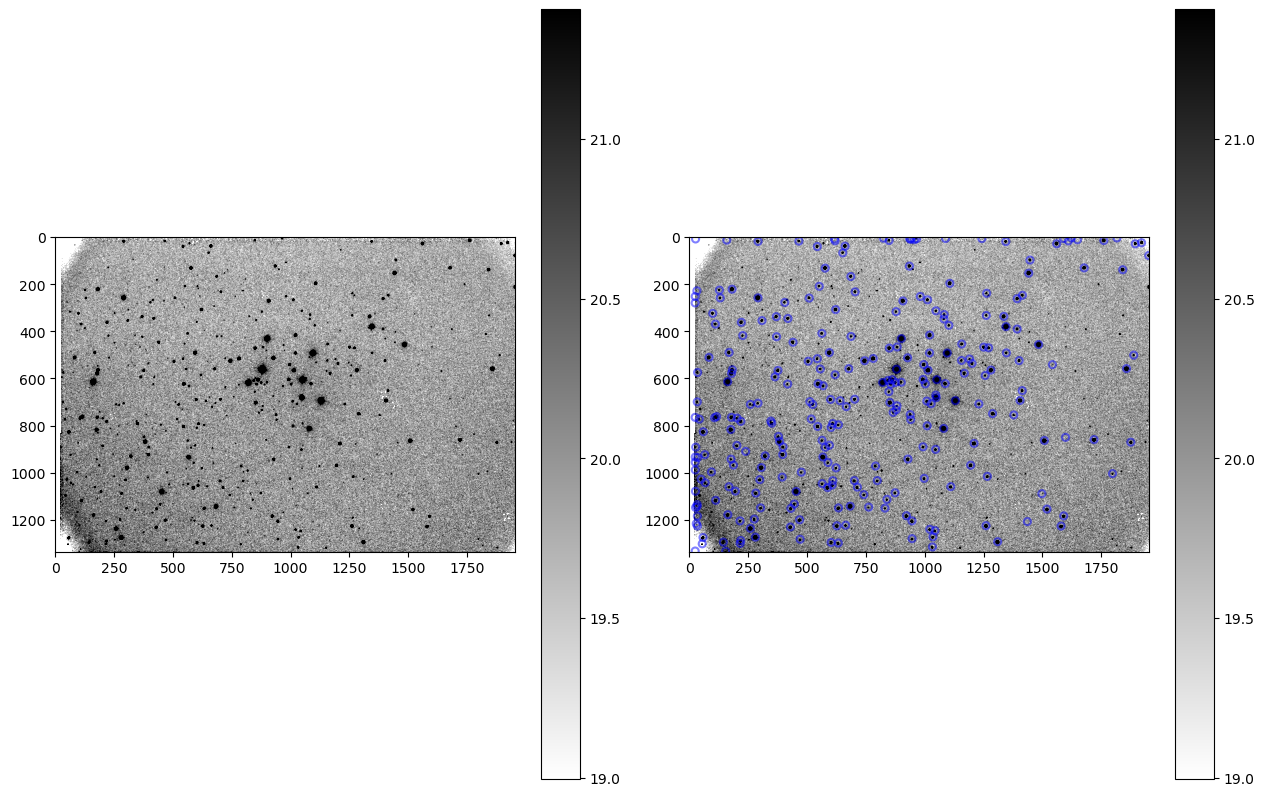

In [15]:
# set up daofind, with info about our image fwhm and the detection threshold
#*****************************************
# update with the FWHM that you measured from the imexam.  
#Use the value below until we get imexam working, or develop an alternative
daofind = DAOStarFinder(fwhm=2.7, threshold=5.*std_b)

# detect sources, using the image - median, which subtracts the sky level from image, 
# assuming a sky that is constant across the iamge
sources_b = daofind(data_b - median_b)

# convert pixel locations of images to ra and dec using the image header
wcs_b = WCS(header_b)
ra_b,dec_b = wcs_b.wcs_pix2world(sources_b['xcentroid'],sources_b['ycentroid'],0)

# plot images and the sources.  using the subplot command we can plot figures side by side
#plots B-band image
plt.figure(figsize=(15,10))
#select the left plot
plt.subplot(1,2,1)
imdisplay(data_b)

#plot B-band image with the positions of the sources overlaid
#select the right plot
plt.subplot(1,2,2)

#Create a list of positions of all the stars, as determined by the DAOStarFinder above.  
#The transpose command puts the images into the correct format
positions = np.transpose((sources_b['xcentroid'], sources_b['ycentroid']))
#creates a set of circular apertues with r=15 pixels
apertures = CircularAperture(positions, r=15.)
imdisplay(data_b)
#plot the apertures.  the ';' at the end suppresses some messy output
apertures.plot(color='blue', lw=1.5, alpha=0.5);

In [16]:
#********************
#repeat for the V-band image
#put your code here

In [17]:
#read in the V-band image
data_v, header_v = fits.getdata('M29V.fits',header=True)

In [18]:
# estimate the background counts in the image by computing the 
# mean and median excluding all pixels greater than 3-sigma above the mean
mean_v, median_v, std_v = sigma_clipped_stats(data_v, sigma=3.0)

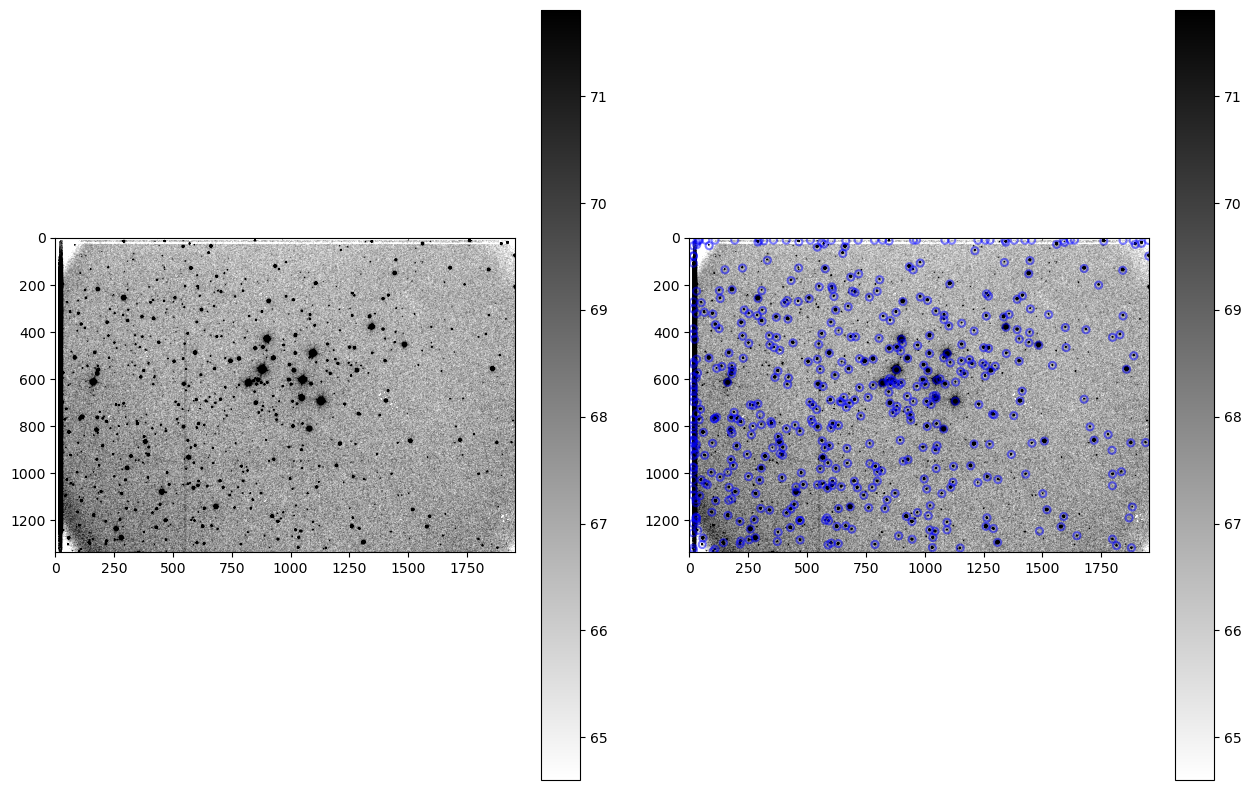

In [19]:
# set up daofind, with info about our image fwhm and the detection threshold
#*****************************************
# update with the FWHM that you measured from imexam
daofind = DAOStarFinder(fwhm=2.7, threshold=5.*std_v)

# detect sources, using the image - median, which subtracts the sky level from image, 
# assuming a sky that is constant across the iamge
sources_v = daofind(data_v - median_v)

# convert to pixel locations to ra and dec using the image header
wcs_v = WCS(header_v)
ra_v,dec_v = wcs_v.wcs_pix2world(sources_v['xcentroid'],sources_v['ycentroid'],0)

# plot images and the sources.  using the subplot command we can plot figures side by side
#plots B-band image
plt.figure(figsize=(15,10))
#select the left plot
plt.subplot(1,2,1)
imdisplay(data_v)

#plot B-band image with the positions of the sources overlaid
#select the right plot
plt.subplot(1,2,2)

#Create a list of positions of all the stars, as determined by the DAOStarFinder above.  
#The transpose command puts the images into the correct format
positions = np.transpose((sources_v['xcentroid'], sources_v['ycentroid']))
#creates a set of circular apertues with r=15 pixels
apertures = CircularAperture(positions, r=15.)
imdisplay(data_v)
#plot the apertures.  the ';' at the end suppresses some messy output
apertures.plot(color='blue', lw=1.5, alpha=0.5);


## Problem 5 - Compare the positions of the V and B-band sources (6 points)

* Make a plot of the DEC vs RA of the sources in the B and V images.
* Plot each set with a separate marker.
* <font color='red'> answer the question </font> Are the same sources detected in each image?  If not, which images has more sources and why?


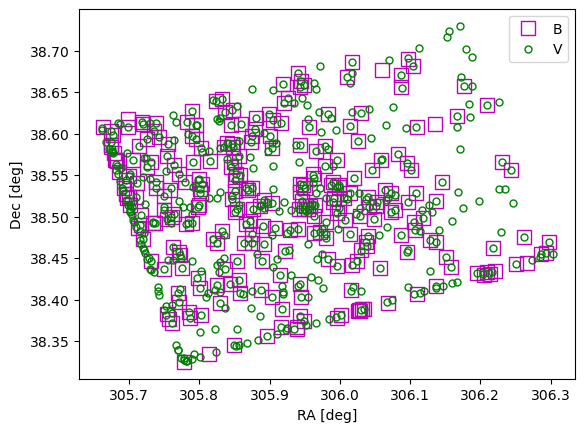

In [20]:
#*************************
# make a plot of the RA and DEC of the sources in the B and V images

# open a figure
plt.figure()

# plot the positions of the B sources
plt.plot(ra_b,dec_b,'ms',mfc='None',markersize=10,label='B')

# plot the positions of the V sources
plt.plot(ra_v,dec_v,'g.',mfc='None',markersize=10,label='V')

# add a legend
plt.legend()

# label your x axis
plt.xlabel('RA [deg]')

# label your y axis
plt.ylabel('Dec [deg]')

# save your plot
plt.savefig('pos_compare.png')


## Match the catalogs of the B and V photometry

We can match the sources in the two catalogs using their RA and DEC

In [21]:
from astropy.coordinates import SkyCoord
from astropy import units as u

In [22]:
#this creates a SkyCoord object containing the B and V catalogs
b_catalog = SkyCoord(ra=ra_b*u.degree, dec=dec_b*u.degree)
v_catalog = SkyCoord(ra=ra_v*u.degree, dec=dec_v*u.degree)

#this matches the two catalogs and outputs an array of indices, idx that when passed to v_catalog
#gives the ids of the match sources in the b_catalog.
idx, d2d, d3d = b_catalog.match_to_catalog_sky(v_catalog)

# we are going to keep matches that have offsets less than 5 arcseconds
# NOTE: this might not be small enough if you were
# matching stars in a globular cluster
matchflag = d2d < 5./3600*u.deg
bmag = sources_b['mag'][matchflag]
vmag = sources_v['mag'][idx[matchflag]]

### Adjust the magnitudes

`daofind` assumes a photometric ZP of zero.  In otherwords, it reports magnitudes as

$$ mag = -2.5 \log_{10}(flux) $$

Compare this to the calibrated magnitudes which we would calculate as:


$$ mag = -2.5 \log_{10}(flux) + ZP$$

Using this and the ZP for each image (reported in the image header as PHOTZP), correct the B and V magnitudes.  

The PHOTZP has been determined by me using PAN-STARRS photometry of stars in our field.

## Problem 6 - convert instrumental magnitudes to calibrated magnitudes (6 points)

In [23]:
#***********************
# your code to convert instrumental magnitudes in each band to calibrated magnitudes.
bmag_cal = bmag + float(header_b['PHOTZP'])
vmag_cal = vmag + float(header_v['PHOTZP'])
print(header_v['PHOTZP'])

17


## Problem 7 - plot a color-magnitude diagram (6 points)

Text(0, 0.5, 'V')

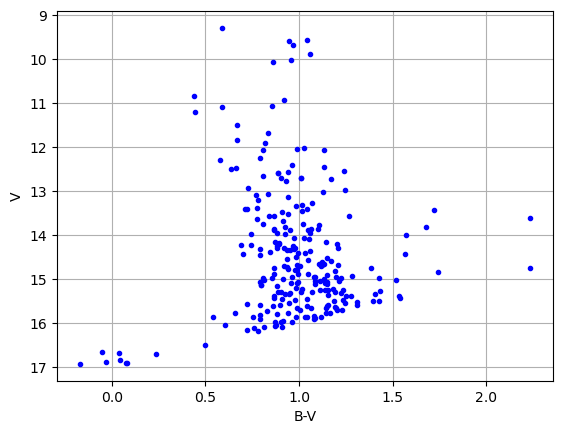

In [24]:
# your figure here
plt.figure()

plt.plot(bmag_cal - vmag_cal, vmag_cal, 'b.')

plt.gca().invert_yaxis()
plt.grid(True)
plt.xlabel('B-V')
plt.ylabel('V')

## Problem 8 - Summarize the CMD (6 points)
Write about the main features of the H-R diagram that you see.  Note that we have not selected members and that there may be contaminants in this field.  I would like you to point out what you think are the astrophysically meaningful regions of this diagram and indicate stars to highlight your points.   If you wish to draw on your figure to annotate it, save the figure and load it into another program, like google slides, to draw on it.

Given that the B and V bands each have their own magnitude limit, describe mathematically the faintest magnitude you see at every color. 


put answer here: There is a main sequence that goes up and to the left.  There is also a small number of stars in the upper right that is the red giant branch.  Stars that are scattered throughout the rest of the diagram are likely Milky Way field stars.

There is also a cutoff along the bottom of the plot that is from our detection limit.